In [1]:
!ls

eval.ipynb
n_seq_sched_1024_rp_1_tlm_beam_grid_search.log
n_seq_sched_1024_rp_2_tlm_beam_grid_search.log
n_seq_sched_1024_rp_3_tlm_beam_grid_search.log
n_seq_sched_131072_rp_1_tlm_beam_grid_search.log
n_seq_sched_131072_rp_2_tlm_beam_grid_search.log
n_seq_sched_131072_rp_3_tlm_beam_grid_search.log
n_seq_sched_16384_rp_1_tlm_beam_grid_search.log
n_seq_sched_16384_rp_2_tlm_beam_grid_search.log
n_seq_sched_16384_rp_3_tlm_beam_grid_search.log
n_seq_sched_2048_rp_1_tlm_beam_grid_search.log
n_seq_sched_2048_rp_2_tlm_beam_grid_search.log
n_seq_sched_2048_rp_3_tlm_beam_grid_search.log
n_seq_sched_32768_rp_1_tlm_beam_grid_search.log
n_seq_sched_32768_rp_2_tlm_beam_grid_search.log
n_seq_sched_32768_rp_3_tlm_beam_grid_search.log
n_seq_sched_4096_rp_1_tlm_beam_grid_search.log
n_seq_sched_4096_rp_2_tlm_beam_grid_search.log
n_seq_sched_4096_rp_3_tlm_beam_grid_search.log
n_seq_sched_65536_rp_1_tlm_beam_grid_search.log
n_seq_sched_65536_rp_2_tlm_beam_grid_search.log
n_seq_sched_65536_rp_3_tlm_beam_gri

In [14]:
get_results(1024)

['./n_seq_sched_1024_rp_1_tlm_beam_grid_seach.log', './n_seq_sched_1024_rp_2_tlm_beam_grid_seach.log', './n_seq_sched_1024_rp_3_tlm_beam_grid_seach.log']


{}

In [4]:
import matplotlib.pyplot as plt
import os

In [85]:
counts = {}
for file in os.listdir('.'):
    if file.endswith('.log'):
        with open(file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                setting = ",".join(line.split(",")[1:]).split(", Dev")[0]
                parts = line.strip().split("Cache Length: ")
                parts = parts[1].split(",")
                cache_len = int(parts[0])
                if cache_len == 1024:
                    if setting not in counts:
                        counts[setting] = 0
                    counts[setting] += 1
counts

{' alpha: 0.42, beta: 1.95, p: 2.96': 8,
 ' alpha: 0.55, beta: 2.92, p: 2.89': 1,
 ' alpha: 0.35, beta: 2.19, p: 3.03': 1,
 ' alpha: 0.53, beta: 2.97, p: 3.53': 1,
 ' alpha: 0.55, beta: 3.0, p: 3.23': 1}

In [79]:
counts

{' alpha: 0.53, beta: 2.97, p: 3.53': 14,
 ' alpha: 0.42, beta: 1.95, p: 2.96': 63,
 ' alpha: 0.35, beta: 2.19, p: 3.03': 12,
 ' alpha: 0.54, beta: 2.96, p: 3.245': 3,
 ' alpha: 0.55, beta: 2.92, p: 2.89': 2,
 ' alpha: 0.55, beta: 3.0, p: 3.23': 5}

In [73]:
def get_results(seq_len):
    paths = [f"./n_seq_sched_{seq_len}_rp_{rp}_tlm_beam_grid_search.log" for rp in [1, 2, 3]]
    paths = [p for p in paths if os.path.exists(p)]
    results = {}
   
    for path in paths:
        with open(path, "r") as f:
            lines = f.readlines()
            for line in lines:
                assert "WER" in line
                parts = line.strip().split("Test WER: ")
                wer = float(parts[1])
                parts = line.strip().split("Cache Length: ")
                parts = parts[1].split(",")
                cache_len = int(parts[0])
                if cache_len not in results:
                    results[cache_len] = []
                results[cache_len].append(wer)
    for k, v in results.items():
        print(len(v))
        if len(v) != 3:
            print(f"Warning: Cache Length {k} has {len(v)} results, expected 3.")
    avg_results = {k: sum(v)/len(v) for k, v in results.items()}
    return avg_results

def get_pdecrease(results):
    sorted_keys = sorted(results.keys())
    print(sorted_keys)
    p_decrease = {}
    for i in range(1, len(sorted_keys)):
        min_val = results[sorted_keys[0]]
        curr_val = results[sorted_keys[i]]
        p_decrease[sorted_keys[i]] = ((min_val - curr_val) / min_val) * 100
        
    return p_decrease

In [75]:
get_results(32768*2)

3
3
2
2


{64: 0.14559973857811,
 128: 0.14409520113827448,
 256: 0.14282213099687519,
 512: 0.1420868819312542}

[64, 128, 256, 512, 1024]
[64, 128, 256, 512, 1024]
[64, 128, 256, 512, 1024]
[64, 128, 256, 512, 1024]
[64, 128, 256, 512]
[64, 128, 256, 512]
[64, 128, 256, 512]


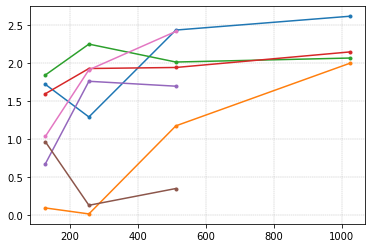

In [ ]:
for seq_len in [1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144]:
    results = get_results(seq_len)
    results = get_pdecrease(results)
    # log scale x axis
    

    plt.plot(list(results.keys()), list(results.values()), label=f"Seq Len {seq_len}", marker='o', markersize=3)
    ax = plt.gca()
    ax.grid(True, which='both', linestyle='--', linewidth=0.4)


# plt.legend(loc='upper right')